# 기준금리 변화와 가계대출 연체율 간 시차 관계 분석

**분석 목적**: 한국은행 기준금리 변화가 가계대출 연체율에 미치는 영향을 시계열 분석을 통해 검증

**가설**: 기준금리가 변하면 가계대출 연체율은 즉각적이 아니라 일정 시간차를 두고 반응할 것이다

**데이터 출처**: 한국은행 경제통계시스템(ECOS), 월별 데이터
- 한국은행 기준금리 (2019.01 ~ 2025.12)
- 예금은행 가계대출 연체율(전체1M, 전국, 국내은행) (2019.12 ~ 2025.12)

**분석 순서**
1. 데이터 전처리
2. 기본/구간별 시각화
3. 원본 데이터 시차 상관관계 분석
4. 구간별 평균 연체율 비교
5. 차분 + ADF 정상성 검정
6. CCF 재분석 (statsmodels)

## 1. 데이터 불러오기 & 전처리

In [24]:
# =====================
# 라이브러리 불러오기
# pandas: 데이터 처리 도구
# matplotlib: 그래프 시각화 도구
# =====================
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 설정 (윈도우 기본 폰트)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [25]:
# =====================
# 데이터 불러오기
# ECOS에서 다운받은 CSV 파일 두 개를 불러옴
# =====================
df_rate = pd.read_csv('base_rate.csv')
df_delinq = pd.read_csv('delinquency_rate.csv')

print(df_rate.head())
print(df_delinq.head())

                        통계표       계정항목  단위   변환  2019/01  2019/02  2019/03  \
0  1.3.1. 한국은행 기준금리 및 여수신금리  한국은행 기준금리  연%  원자료     1.75     1.75     1.75   

   2019/04  2019/05  2019/06  ...  2025/03  2025/04  2025/05  2025/06  \
0     1.75     1.75     1.75  ...     2.75     2.75      2.5      2.5   

   2025/07  2025/08  2025/09  2025/10  2025/11  2025/12  
0      2.5      2.5      2.5      2.5      2.5      2.5  

[1 rows x 88 columns]
                     통계표              계정항목 지역코드            보고기관 단위   변환  \
0  1.2.3.7. 예금은행 지역별 연체율    가계대출 연체율(전체1M)   전국  국내은행(수출입은행 포함)  %  원자료   

   2019/12  2020/01  2020/02  2020/03  ...  2025/03  2025/04  2025/05  \
0     0.26     0.29      0.3     0.27  ...     0.41     0.43     0.47   

   2025/06  2025/07  2025/08  2025/09  2025/10  2025/11  2025/12  
0     0.41     0.43     0.45     0.39     0.42     0.44     0.38  

[1 rows x 79 columns]


In [26]:
# =====================
# Wide → Long 변환
# 날짜가 가로로 펼쳐진 구조를 세로로 바꿈
# melt(): 가로 구조를 세로 구조로 변환하는 함수
# =====================

# 기준금리 전처리
df_rate = df_rate[['계정항목'] + [c for c in df_rate.columns if '/' in c]]
df_rate = df_rate.melt(id_vars='계정항목', var_name='날짜', value_name='기준금리')
df_rate = df_rate[df_rate['계정항목'] == '한국은행 기준금리'].drop(columns='계정항목')

# 연체율 전처리
df_delinq = df_delinq[[c for c in df_delinq.columns if '/' in c]]
df_delinq = df_delinq.melt(var_name='날짜', value_name='연체율')

print(df_rate.head())
print(df_delinq.head())

        날짜  기준금리
0  2019/01  1.75
1  2019/02  1.75
2  2019/03  1.75
3  2019/04  1.75
4  2019/05  1.75
        날짜   연체율
0  2019/12  0.26
1  2020/01  0.29
2  2020/02  0.30
3  2020/03  0.27
4  2020/04  0.29


In [27]:
# =====================
# 데이터 합치기 & 날짜 형식 변환
# merge(): 두 데이터를 날짜 기준으로 하나로 합치는 함수 (겹치는 기간만 자동으로 맞춰짐)
# to_datetime(): 문자열을 날짜 형식으로 변환하는 함수
# =====================
df = pd.merge(df_rate, df_delinq, on='날짜')
df['날짜'] = pd.to_datetime(df['날짜'],format='%Y/%m')

print(df.dtypes)
print(df.head())
print(f'총 {df.shape[0]}개월 데이터')

날짜      datetime64[ns]
기준금리           float64
연체율            float64
dtype: object
          날짜  기준금리   연체율
0 2019-12-01  1.25  0.26
1 2020-01-01  1.25  0.29
2 2020-02-01  1.25  0.30
3 2020-03-01  0.75  0.27
4 2020-04-01  0.75  0.29
총 73개월 데이터


## 2. 기본 시각화

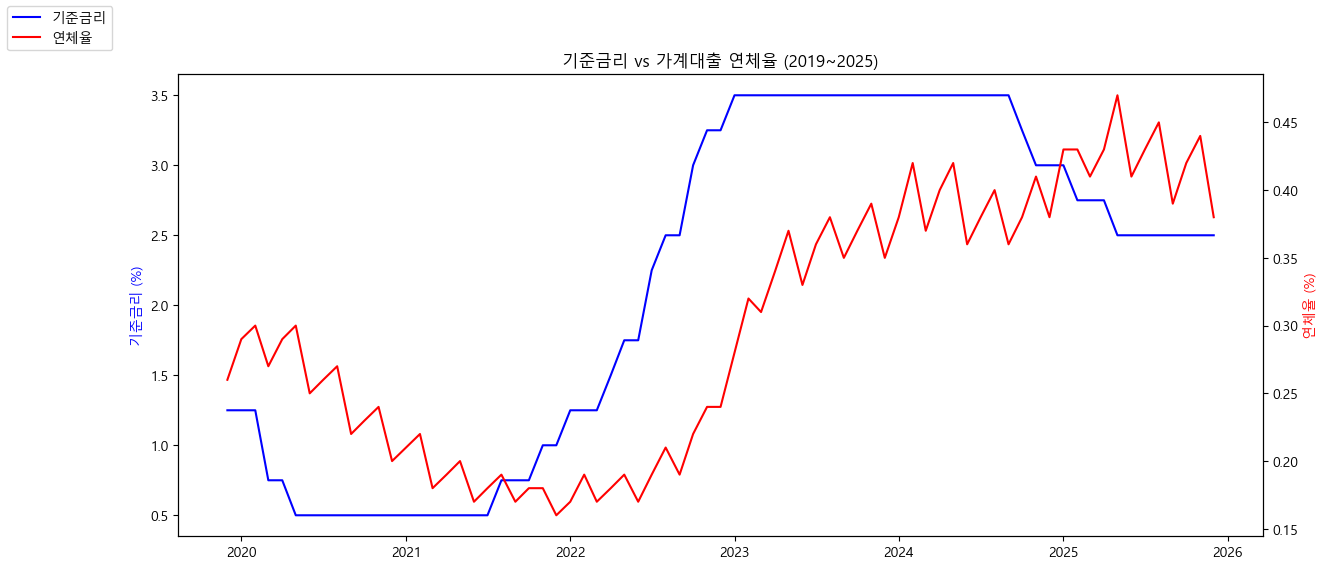

In [28]:
# =====================
# 기준금리 vs 연체율 기본 시각화
# twinx(): y축을 두 개 만드는 함수 (기준금리와 연체율 단위가 달라서)
# =====================
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df['날짜'], df['기준금리'], color='blue', label='기준금리')
ax1.set_ylabel('기준금리 (%)', color='blue')

ax2 = ax1.twinx()
ax2.plot(df['날짜'], df['연체율'], color='red', label='연체율')
ax2.set_ylabel('연체율 (%)', color='red')

plt.title('기준금리 vs 가계대출 연체율 (2019~2025)')
fig.legend(loc='upper left')
plt.show()

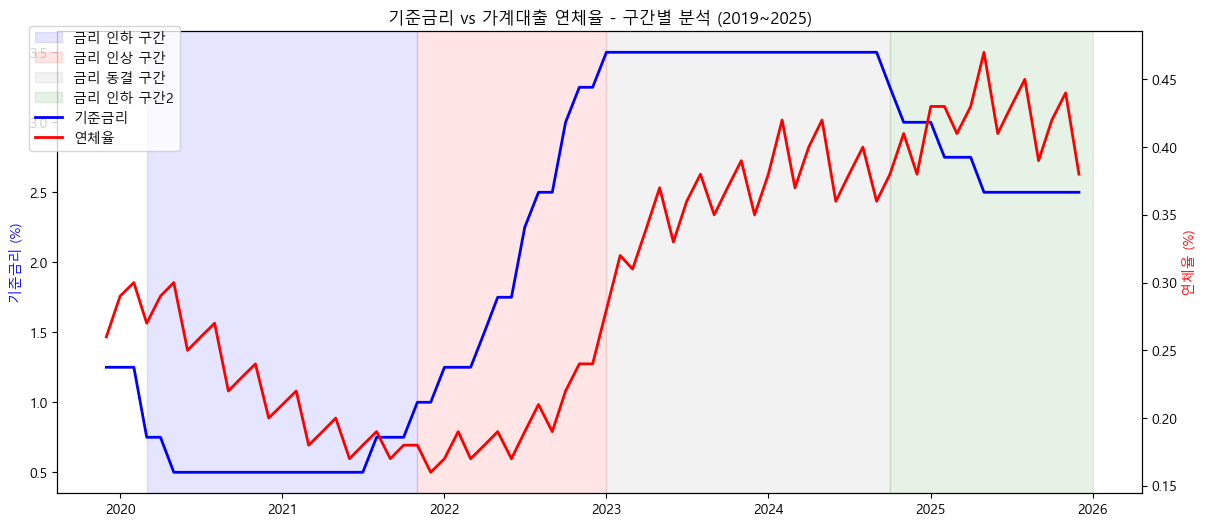

In [29]:
# =====================
# 금리 구간별 시각화
# axvspan(): 특정 기간을 색으로 칠해주는 함수
# 금리 인하/인상/동결 구간을 색으로 구분해서 패턴을 시각적으로 확인
# =====================
fig, ax1 = plt.subplots(figsize=(14, 6))

# 구간 색칠
ax1.axvspan(pd.Timestamp('2020-03'), pd.Timestamp('2021-11'), alpha=0.1, color='blue', label='금리 인하 구간')
ax1.axvspan(pd.Timestamp('2021-11'), pd.Timestamp('2023-01'), alpha=0.1, color='red', label='금리 인상 구간')
ax1.axvspan(pd.Timestamp('2023-01'), pd.Timestamp('2024-10'), alpha=0.1, color='gray', label='금리 동결 구간')
ax1.axvspan(pd.Timestamp('2024-10'), pd.Timestamp('2026-01'), alpha=0.1, color='green', label='금리 인하 구간2')

# 기준금리
ax1.plot(df['날짜'], df['기준금리'], color='blue', linewidth=2, label='기준금리')
ax1.set_ylabel('기준금리 (%)', color='blue')

# 연체율
ax2 = ax1.twinx()
ax2.plot(df['날짜'], df['연체율'], color='red', linewidth=2, label='연체율')
ax2.set_ylabel('연체율 (%)', color='red')

plt.title('기준금리 vs 가계대출 연체율 - 구간별 분석 (2019~2025)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.show()

## 3. 1차 분석 - 원본 데이터 시차 상관관계

기준금리와 연체율의 **원본 값**을 가지고, 0~12개월 시차를 적용했을 때 상관관계가 어떻게 달라지는지 확인한다.

In [30]:
# =====================
# 시차 상관관계 분석 (원본 데이터)
# 0~12개월 시차를 바꿔가며 기준금리와 연체율의 상관관계를 계산
# corr(): 두 변수의 상관관계를 계산하는 함수 (-1 ~ 1)
# shift(): 데이터를 시간축으로 밀어주는 함수
# =====================
correlations = {}

for lag in range(0, 13):
    correlations[lag] = df['기준금리'].corr(df['연체율'].shift(-lag))

for lag, corr in correlations.items():
    print(f'시차 {lag:2d}개월 후 상관관계: {corr:.3f}')

시차  0개월 후 상관관계: 0.698
시차  1개월 후 상관관계: 0.743
시차  2개월 후 상관관계: 0.784
시차  3개월 후 상관관계: 0.830
시차  4개월 후 상관관계: 0.864
시차  5개월 후 상관관계: 0.891
시차  6개월 후 상관관계: 0.921
시차  7개월 후 상관관계: 0.938
시차  8개월 후 상관관계: 0.948
시차  9개월 후 상관관계: 0.958
시차 10개월 후 상관관계: 0.958
시차 11개월 후 상관관계: 0.952
시차 12개월 후 상관관계: 0.947


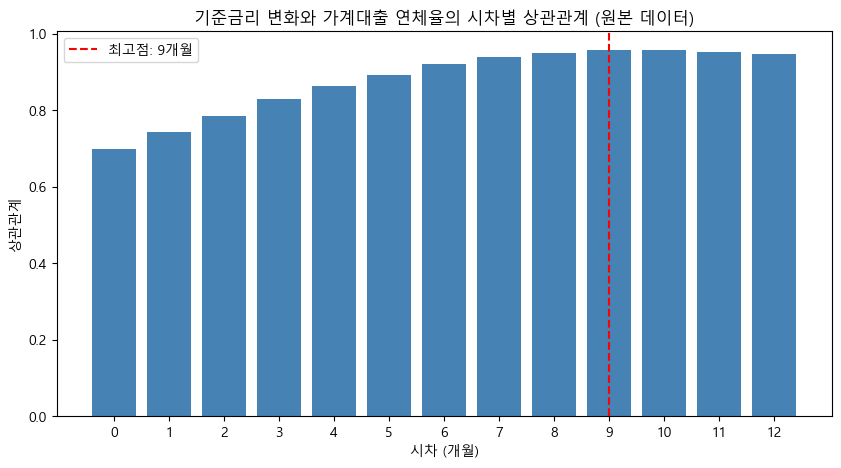

In [31]:
# =====================
# 시차별 상관관계 시각화
# 어느 시차에서 상관관계가 가장 높은지 막대 그래프로 표현
# axvline(): 특정 지점에 세로 기준선을 그어주는 함수
# =====================
corr_series = pd.Series(correlations)

plt.figure(figsize=(10, 5))
plt.bar(corr_series.index, corr_series.values, color='steelblue')
plt.axvline(x=corr_series.idxmax(), color='red', linestyle='--', label=f'최고점: {corr_series.idxmax()}개월')
plt.xlabel('시차 (개월)')
plt.ylabel('상관관계')
plt.title('기준금리 변화와 가계대출 연체율의 시차별 상관관계 (원본 데이터)')
plt.xticks(range(0, 13))
plt.legend()
plt.show()

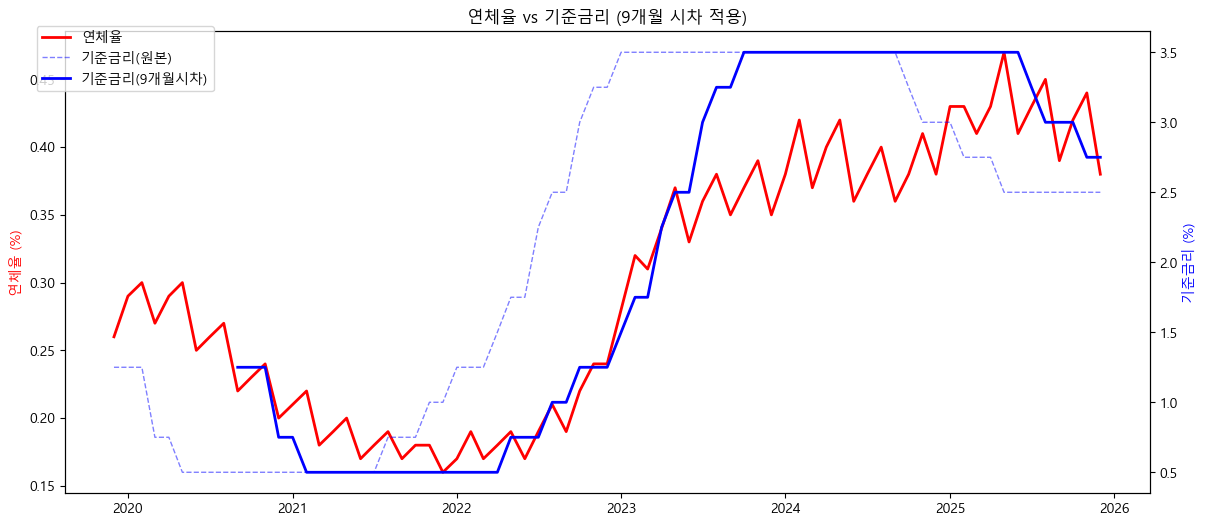

In [33]:
# =====================
# 9개월 시차 적용 시각화
# 기준금리를 9개월 앞으로 밀어서 연체율과 겹쳐 그림
# 시차를 적용했을 때 두 선이 얼마나 일치하는지 시각적으로 확인
# =====================
df['기준금리_9개월시차'] = df['기준금리'].shift(9)

fig, ax1 = plt.subplots(figsize=(14, 6))


# 연체율
ax1.plot(df['날짜'], df['연체율'], color='red', linewidth=2, label='연체율')
ax1.set_ylabel('연체율 (%)', color='red')

# 기준금리 (원본)
ax2 = ax1.twinx()
ax2.plot(df['날짜'], df['기준금리'], color='blue', linewidth=1, linestyle='--', alpha=0.5, label='기준금리(원본)')

# 기준금리 (9개월 시차 적용)
ax2.plot(df['날짜'], df['기준금리_9개월시차'], color='blue', linewidth=2, label='기준금리(9개월시차)')
ax2.set_ylabel('기준금리 (%)', color='blue')

plt.title('연체율 vs 기준금리 (9개월 시차 적용)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.show()

## 4. 구간별 평균 연체율 비교

구간
①금리인하전      0.283333
②금리인하구간     0.221000
③금리인상구간     0.192857
④금리동결구간     0.363810
⑤금리인하구간2    0.417333
Name: 연체율, dtype: float64


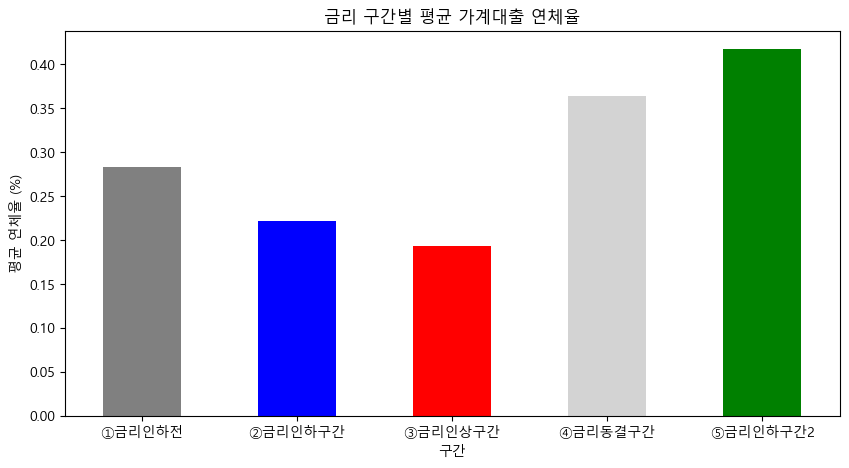

In [10]:
# =====================
# 구간별 평균 연체율 비교
# groupby(): 그룹별로 묶어서 평균을 계산하는 함수
# 금리 구간별로 연체율 평균을 비교해서 시차 효과를 수치로 확인
# =====================

# 구간 라벨 붙이기
def get_period(date):
    if date < pd.Timestamp('2020-03'):
        return '①금리인하전'
    elif date < pd.Timestamp('2021-11'):
        return '②금리인하구간'
    elif date < pd.Timestamp('2023-01'):
        return '③금리인상구간'
    elif date < pd.Timestamp('2024-10'):
        return '④금리동결구간'
    else:
        return '⑤금리인하구간2'

df['구간'] = df['날짜'].apply(get_period)

# 구간별 평균 연체율 계산
avg_by_period = df.groupby('구간')['연체율'].mean()
print(avg_by_period)

# 막대 그래프
plt.figure(figsize=(10, 5))
avg_by_period.plot(kind='bar', color=['gray', 'blue', 'red', 'lightgray', 'green'])
plt.title('금리 구간별 평균 가계대출 연체율')
plt.xlabel('구간')
plt.ylabel('평균 연체율 (%)')
plt.xticks(rotation=0)
plt.show()

## 5. 차분 & ADF 정상성 검정

1차 분석의 0.958이라는 상관관계가 너무 높게 나왔다. 이것이 진짜 관계인지, 아니면 두 시계열이 같은 방향의 추세(trend)를 가지고 있어서 생긴 **가성 상관관계(spurious correlation)**인지 확인이 필요하다.

이를 위해 먼저 **차분(변화량)** 을 계산하고, **ADF 검정**으로 정상성(추세 존재 여부)을 확인한다.

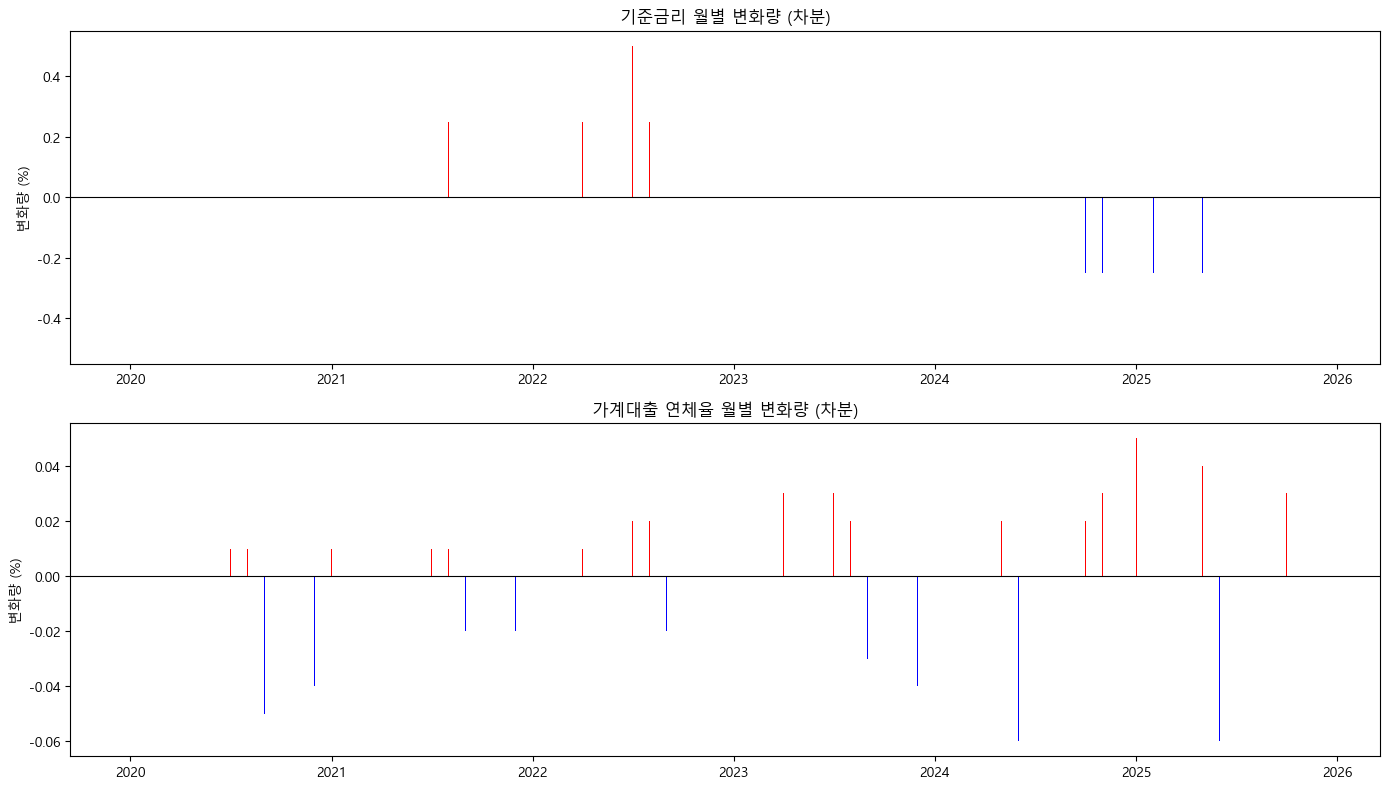

In [11]:
# =====================
# 차분 계산 & 시각화
# diff(): 이번 값 - 이전 값을 계산하는 함수 (변화량)
# 금리/연체율이 '언제 얼마나' 변했는지를 보여줌
# =====================
df['기준금리_차분'] = df['기준금리'].diff()
df['연체율_차분'] = df['연체율'].diff()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# 기준금리 차분
ax1.bar(df['날짜'], df['기준금리_차분'], color=df['기준금리_차분'].apply(lambda x: 'red' if x > 0 else ('blue' if x < 0 else 'gray')))
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.set_title('기준금리 월별 변화량 (차분)')
ax1.set_ylabel('변화량 (%)')

# 연체율 차분
ax2.bar(df['날짜'], df['연체율_차분'], color=df['연체율_차분'].apply(lambda x: 'red' if x > 0 else ('blue' if x < 0 else 'gray')))
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_title('가계대출 연체율 월별 변화량 (차분)')
ax2.set_ylabel('변화량 (%)')

plt.tight_layout()
plt.show()

In [12]:
# =====================
# ADF 정상성 검정
# ADF 검정: 시계열이 안정적(정상)인지 통계적으로 확인
# p-value < 0.05 이면 정상 시계열
# p-value > 0.05 이면 비정상 시계열 (추세 존재)
# =====================
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f'[{name}]')
    print(f'ADF 통계량: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'결론: {"정상 시계열 (추세 없음)" if result[1] < 0.05 else "비정상 시계열 (추세 존재)"}')
    print()   

adf_test(df['기준금리'], '기준금리 원시계열')
adf_test(df['연체율'], '연체율 원시계열')
adf_test(df['기준금리_차분'], '기준금리 차분')
adf_test(df['연체율_차분'], '연체율 차분')

[기준금리 원시계열]
ADF 통계량: -2.2884
p-value: 0.1757
결론: 비정상 시계열 (추세 존재)

[연체율 원시계열]
ADF 통계량: -1.1620
p-value: 0.6897
결론: 비정상 시계열 (추세 존재)

[기준금리 차분]
ADF 통계량: -2.3868
p-value: 0.1455
결론: 비정상 시계열 (추세 존재)

[연체율 차분]
ADF 통계량: -2.6375
p-value: 0.0855
결론: 비정상 시계열 (추세 존재)



**검정 결과**: ADF 검정 결과 원본 시계열은 비정상성을 보였으며, 차분 후에도 정상성이 충분히 확보되지 않았다. 이는 분석 기간(2019~2025) 동안 금리 정책 국면 변화 등 구조적 변화가 존재했을 가능성을 시사한다.

즉, 1차 분석의 0.958은 두 시계열이 같은 방향의 추세를 갖고 있어서 부풀려진 가성 상관관계일 가능성이 있다. 추세를 제거한 **차분 데이터로 CCF를 재계산**하여 더 정직한 관계를 확인한다.

## 6. 2차 분석 - CCF (차분 데이터, statsmodels)

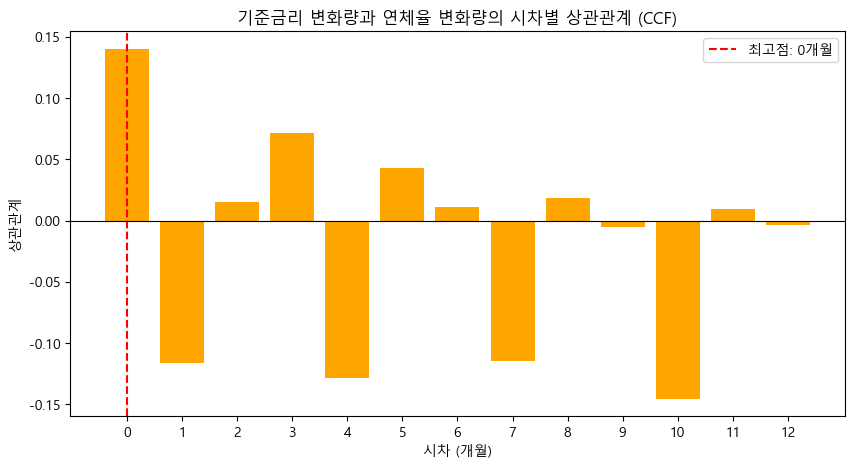

시차  0개월 후 상관관계: 0.140
시차  1개월 후 상관관계: -0.116
시차  2개월 후 상관관계: 0.015
시차  3개월 후 상관관계: 0.071
시차  4개월 후 상관관계: -0.128
시차  5개월 후 상관관계: 0.043
시차  6개월 후 상관관계: 0.011
시차  7개월 후 상관관계: -0.115
시차  8개월 후 상관관계: 0.018
시차  9개월 후 상관관계: -0.005
시차 10개월 후 상관관계: -0.145
시차 11개월 후 상관관계: 0.010
시차 12개월 후 상관관계: -0.004


In [13]:
# =====================
# CCF (교차상관) 분석 - 차분 데이터 사용
# ccf(): 두 시계열 간 시차별 상관관계를 계산하는 표준 함수
# 추세를 제거한 변화량(차분) 기준이라 더 정직한 관계를 보여줌
# =====================
from statsmodels.tsa.stattools import ccf

x = df['기준금리_차분'].dropna()
y = df['연체율_차분'].dropna()

ccf_values = ccf(x, y, adjusted=False)

# 0~12개월 시차만 확인
ccf_12 = ccf_values[:13]

plt.figure(figsize=(10, 5))
plt.bar(range(13), ccf_12, color='orange')
plt.axvline(x=ccf_12.argmax(), color='red', linestyle='--', label=f'최고점: {ccf_12.argmax()}개월')
plt.xlabel('시차 (개월)')
plt.ylabel('상관관계')
plt.title('기준금리 변화량과 연체율 변화량의 시차별 상관관계 (CCF)')
plt.xticks(range(0, 13))
plt.axhline(y=0, color='black', linewidth=0.8)
plt.legend()
plt.show()

for lag, val in enumerate(ccf_12):
    print(f'시차 {lag:2d}개월 후 상관관계: {val:.3f}')

## 결론

### 분석 과정 요약
| 단계 | 방법 | 결과 |
|------|------|------|
| 1차 분석 | 원본 데이터 시차 상관관계 | 9개월 시차에서 0.958 (최고점) |
| 정상성 검정 | ADF 검정 | 원본/차분 모두 비정상 → 가성 상관관계 가능성 |
| 2차 분석 | 차분 데이터 CCF (statsmodels) | 뚜렷한 시차 패턴 미확인 |

1차 분석에서 9개월 시차일 때 상관관계가 0.958로 매우 높게 나타났으나, ADF 검정 결과 두 시계열 모두 비정상성을 보였다. 이는 원본 데이터의 높은 상관관계가 두 시계열의 공통 추세에 의한 가성 상관관계였을 가능성을 시사한다.

추세를 제거한 차분 데이터로 CCF를 재분석한 결과, 뚜렷한 시차 패턴은 확인되지 않았다. 시각적으로는 금리 인상 이후 연체율 상승 패턴이 관찰되었으나, 이는 단기 변화량보다 중장기 추세 수준에서 작동하는 관계일 가능성이 높다. 또한 분석에 사용된 데이터가 73개월로 충분하지 않아 차분 후 노이즈가 커진 영향도 있다.

### 최종 해석
기준금리와 가계대출 연체율은 9개월 시차에서 가장 강한 동행 패턴을 보였다. 이는 기준금리 변화가 가계대출 연체율에 즉각 반영되기보다 일정 기간 이후 반영될 가능성을 시사한다. 다만 본 분석은 상관관계 기반의 탐색적 분석이므로 인과관계로 단정하기보다는, 더 긴 데이터 기간 확보와 추가적인 회귀분석 또는 시계열 모형을 통한 검증이 필요하다.

### 분석의 한계
- 데이터 기간(73개월)이 짧아 차분 후 통계적 검정력이 낮음
- 분석 기간 내 금리 정책 국면이 여러 차례 전환되어 구조적 변화 존재
- 상관관계 기반 분석으로 인과관계 확인 불가

### 시사점
금융기관은 기준금리 변화 이후 **약 9개월 전후 시차를 두고 연체율이 반응할 가능성**을 고려하여 모니터링 체계를 운영할 필요가 있다.